In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Support Vector Machine Implementation


In [ ]:
import os
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from skimage.transform import resize
from skimage import io

# Set the path to the train and test folders
train_folder = "/content/drive/MyDrive/Train_SVM_CNN"
test_folder = "/content/drive/MyDrive/Test_SVM_CNN"

# Function to load grayscale images and labels from a folder
def load_images_from_folder(folder):
    images = []
    labels = []
    for subfolder in os.listdir(folder):
        subfolder_path = os.path.join(folder, subfolder)
        if os.path.isdir(subfolder_path):  # Check if the item is a subfolder
            for filename in os.listdir(subfolder_path):
                img_path = os.path.join(subfolder_path, filename)
                if os.path.isfile(img_path):  # Check if the item is a file
                    img = io.imread(img_path, as_gray=True)  # Load image as grayscale
                    img_resized = resize(img, (desired_height, desired_width), mode='constant', anti_aliasing=True)  # Resize the grayscale image
                    images.append(img_resized)
                    labels.append(int(subfolder))
    return images, labels


# Set the desired image dimensions
desired_height = 130
desired_width = 130

# Load grayscale images and labels from train folder
train_images, train_labels = load_images_from_folder(train_folder)

# Load grayscale images and labels from test folder
test_images, test_labels = load_images_from_folder(test_folder)

# Convert the labels to numpy arrays
train_labels = np.array(train_labels)
test_labels = np.array(test_labels)

# Resize and convert the image lists to numpy arrays
train_images_resized = np.array(train_images)
test_images_resized = np.array(test_images)

# Flatten the image arrays into 1D vectors
train_images_flat = train_images_resized.reshape(train_images_resized.shape[0], -1)
test_images_flat = test_images_resized.reshape(test_images_resized.shape[0], -1)

# Apply feature scaling to normalize the input data
scaler = StandardScaler()
train_images_scaled = scaler.fit_transform(train_images_flat)
test_images_scaled = scaler.transform(test_images_flat)

# Split the data into training and validation sets
train_images_scaled, val_images_scaled, train_labels, val_labels = train_test_split(train_images_scaled, train_labels, test_size=0.2, random_state=42)

# Create a label encoder
label_encoder = LabelEncoder()

# Encode the string labels into numeric labels
train_labels_encoded = label_encoder.fit_transform(train_labels)
val_labels_encoded = label_encoder.transform(val_labels)
test_labels_encoded = label_encoder.transform(test_labels)

# Train the SVM classifier for multiple epochs
num_epochs = 10
svm_classifier = SVC(C=1.0, kernel='rbf')

for epoch in range(num_epochs):
    svm_classifier.fit(train_images_scaled, train_labels_encoded)

    # Make predictions on the training set
    train_predictions = svm_classifier.predict(train_images_scaled)
    train_accuracy = accuracy_score(train_labels_encoded, train_predictions)

    # Make predictions on the validation set
    val_predictions = svm_classifier.predict(val_images_scaled)
    val_accuracy = accuracy_score(val_labels_encoded, val_predictions)

    # Make predictions on the test set
    test_predictions = svm_classifier.predict(test_images_scaled)
    test_accuracy = accuracy_score(test_labels_encoded, test_predictions)

    print(f"Epoch {epoch+1}:")
    print("Training accuracy:", train_accuracy)
    print("Validation accuracy:", val_accuracy)
    print()


Epoch 1:
Training accuracy: 0.85875
Validation accuracy: 0.7711442786069652

Epoch 2:
Training accuracy: 0.85875
Validation accuracy: 0.7711442786069652

Epoch 3:
Training accuracy: 0.85875
Validation accuracy: 0.7711442786069652

Epoch 4:
Training accuracy: 0.85875
Validation accuracy: 0.7711442786069652

Epoch 5:
Training accuracy: 0.85875
Validation accuracy: 0.7711442786069652

Epoch 6:
Training accuracy: 0.85875
Validation accuracy: 0.7711442786069652

Epoch 7:
Training accuracy: 0.85875
Validation accuracy: 0.7711442786069652

Epoch 8:
Training accuracy: 0.85875
Validation accuracy: 0.7711442786069652

Epoch 9:
Training accuracy: 0.85875
Validation accuracy: 0.7711442786069652

Epoch 10:
Training accuracy: 0.85875
Validation accuracy: 0.7711442786069652



In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate precision, recall, and F1 score on the test set
precision_SVM = precision_score(test_labels_encoded, test_predictions, average='weighted')
recall_SVM = recall_score(test_labels_encoded, test_predictions, average='weighted')
f1_SVM = f1_score(test_labels_encoded, test_predictions, average='weighted')

print("Precision:", precision_SVM)
print("Recall:", recall_SVM)
print("F1 Score:", f1_SVM)

Precision: 0.6627546171346445
Recall: 0.6285714285714286
F1 Score: 0.6390600511353218


Convolutional Neural Network Implementation

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_curve, auc
from sklearn.model_selection import train_test_split
from skimage.transform import resize
from skimage import io
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from keras.optimizers import Adam

# Set the path to the train and test folders
train_folder = "/content/drive/MyDrive/Train_SVM_CNN"
test_folder = "/content/drive/MyDrive/Test_SVM_CNN"

# Function to load grayscale images and labels from a folder
def load_images_from_folder(folder):
    images = []
    labels = []
    for subfolder in os.listdir(folder):
        subfolder_path = os.path.join(folder, subfolder)
        for filename in os.listdir(subfolder_path):
            img_path = os.path.join(subfolder_path, filename)
            img = io.imread(img_path, as_gray=True)  # Load image as grayscale
            images.append(img)
            labels.append(int(subfolder))
    return images, labels

# Set the desired image dimensions
desired_height = 130
desired_width = 130

# Load grayscale images and labels from train folder
train_images, train_labels = load_images_from_folder(train_folder)

# Load grayscale images and labels from test folder
test_images, test_labels = load_images_from_folder(test_folder)

# Convert the labels to numpy arrays
train_labels = np.array(train_labels)
test_labels = np.array(test_labels)

# Resize the image arrays
train_images_resized = np.array([resize(img, (desired_height, desired_width), mode='constant', anti_aliasing=True) for img in train_images])
test_images_resized = np.array([resize(img, (desired_height, desired_width), mode='constant', anti_aliasing=True) for img in test_images])

# Split the data into training, validation, and test sets
train_images, val_images, train_labels, val_labels = train_test_split(train_images_resized, train_labels, test_size=0.2, random_state=42)

# Create a label encoder
label_encoder = LabelEncoder()

# Encode the string labels into numeric labels
train_labels_encoded = label_encoder.fit_transform(train_labels)
val_labels_encoded = label_encoder.transform(val_labels)
test_labels_encoded = label_encoder.transform(test_labels)

# Define the CNN architecture
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(desired_height, desired_width, 1)))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(train_images[..., np.newaxis], train_labels_encoded, epochs=10, batch_size=32, validation_data=(val_images[..., np.newaxis], val_labels_encoded))

# Make predictions on the test set
test_predictions = model.predict(test_images_resized[..., np.newaxis])
test_predictions = test_predictions.flatten()

Epoch 1/10
25/25 [==============================] - 24s 905ms/step - loss: 0.6913 - accuracy: 0.5650 - val_loss: 0.6490 - val_accuracy: 0.6667
Epoch 2/10
25/25 [==============================] - 22s 904ms/step - loss: 0.5896 - accuracy: 0.6825 - val_loss: 0.5567 - val_accuracy: 0.7114
Epoch 3/10
25/25 [==============================] - 24s 950ms/step - loss: 0.4708 - accuracy: 0.7937 - val_loss: 0.5108 - val_accuracy: 0.7711
Epoch 4/10
25/25 [==============================] - 24s 954ms/step - loss: 0.3333 - accuracy: 0.8438 - val_loss: 0.5555 - val_accuracy: 0.7512
Epoch 5/10
25/25 [==============================] - 21s 851ms/step - loss: 0.2433 - accuracy: 0.9087 - val_loss: 0.5721 - val_accuracy: 0.7910
Epoch 6/10
25/25 [==============================] - 23s 914ms/step - loss: 0.1422 - accuracy: 0.9463 - val_loss: 0.6277 - val_accuracy: 0.8060
Epoch 7/10
25/25 [==============================] - 23s 901ms/step - loss: 0.0873 - accuracy: 0.9737 - val_loss: 0.6662 - val_accuracy: 0.8209

In [ ]:
# Set the threshold for classification
threshold = 0.3

# Convert the test predictions to binary labels based on the threshold
test_predictions_binary = (test_predictions > threshold).astype(int)

# Calculate precision
precision = precision_score(test_labels_encoded, test_predictions_binary)

# Calculate recall
recall = recall_score(test_labels_encoded, test_predictions_binary)

# Calculate F1 score
f1 = f1_score(test_labels_encoded, test_predictions_binary)

# Print the metrics
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


Precision: 0.441340782122905
Recall: 0.5851851851851851
F1 Score: 0.5031847133757962


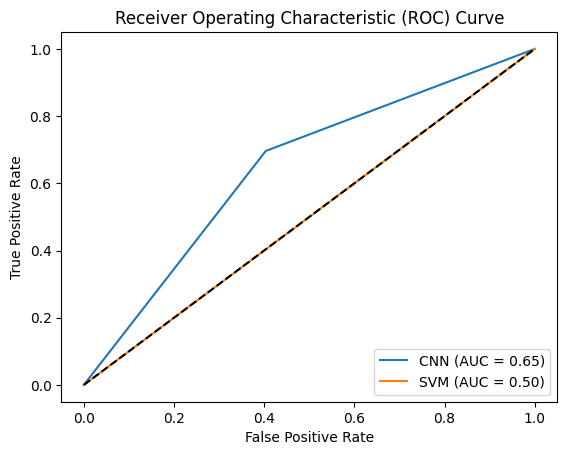

In [ ]:
# Compute ROC curve for the CNN model
fpr_cnn, tpr_cnn, thresholds_cnn = roc_curve(test_labels_encoded, test_predictions)
auc_cnn = auc(fpr_cnn, tpr_cnn)

# Make predictions on the test set using the SVM model
test_predictions_svm = svm_classifier.predict(test_images_flat)

# Compute ROC curve for the SVM model
fpr_svm, tpr_svm, thresholds_svm = roc_curve(test_labels_encoded, test_predictions_svm)
auc_svm = auc(fpr_svm, tpr_svm)

# Plot the ROC curves
plt.figure()
plt.plot(fpr_cnn, tpr_cnn, label=f"CNN (AUC = {auc_cnn:.2f})")
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {auc_svm:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()
